In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
df.dtypes


LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [3]:
# CLEAN FEATURES PROPERLY

# Separate features & target
X = df.drop("Default", axis=1)
y = df["Default"]

# CHECK object columns (IMPORTANT)
print("Object columns before fix:")
print(X.select_dtypes(include='object').columns)

# DROP ALL object/string columns (IDs, codes, text)
X = X.select_dtypes(exclude='object')

# VERIFY again
print("\nObject columns after fix:")
print(X.select_dtypes(include='object').columns)

print("\nFinal dtypes:")
print(X.dtypes)


Object columns before fix:
Index(['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

Object columns after fix:
Index([], dtype='object')

Final dtypes:
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
dtype: object


In [4]:
import pandas as pd

# Load data
df = pd.read_csv("Loan_default.csv")   # use exact file name

# Drop ID-like columns (random codes)
for col in df.columns:
    if df[col].dtype == "object" and df[col].nunique() > 100:
        df.drop(col, axis=1, inplace=True)

# Encode remaining categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# Final check
print(df.dtypes)


Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education           int64
EmploymentType      int64
MaritalStatus       int64
HasMortgage         int64
HasDependents       int64
LoanPurpose         int64
HasCoSigner         int64
Default             int64
dtype: object


# SUPERVISED LEARNING LOGISTIC REGRESSION ALGORITHM

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Feature & target split
# Select ONLY user-input features
features = ["Age", "Income", "CreditScore", "LoanAmount"]

X = df[features]
y = df["Default"]


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "logistic_model.pkl")



# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

import joblib
joblib.dump(model, "logistic_model.pkl")


# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8844722929312708

Confusion Matrix:
 [[45170     0]
 [ 5900     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94     45170
           1       0.00      0.00      0.00      5900

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



c:\Users\manas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\manas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
X

,Age,Income,CreditScore,LoanAmount
0,56,85994,520,50587
1,69,50432,458,124440
2,46,84208,451,129188
3,32,31713,743,44799
4,60,20437,633,9139
...,...,...,...,...
255342,19,37979,541,210682
255343,32,51953,511,189899
255344,56,84820,597,208294
255345,42,85109,809,60575


In [13]:
y

0         0
1         0
2         1
3         0
4         0
         ..
255342    0
255343    1
255344    0
255345    0
255346    0
Name: Default, Length: 255347, dtype: int64

In [14]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [15]:
y_test

51139     0
71005     0
35684     0
174087    0
137952    0
         ..
35991     0
69680     0
184743    0
209406    0
123164    0
Name: Default, Length: 51070, dtype: int64

# Logistic regression visualization - confusion matrix

This confusion matrix shows how well the Logistic Regression model classifies defaulters and non-defaulters.


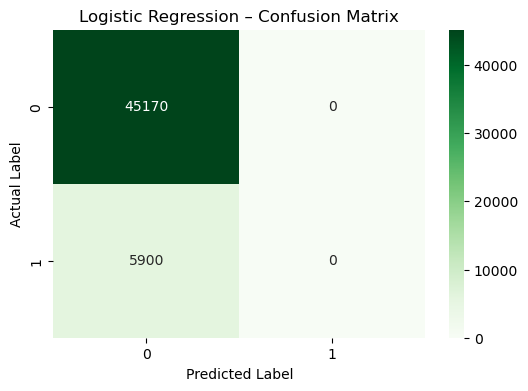

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("This confusion matrix shows how well the Logistic Regression model classifies defaulters and non-defaulters.")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


# KNN

In [7]:
# Import KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train KNN Model
# (we’ll start with k = 5, standard choice)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

#  Predictions

y_pred_knn = knn.predict(X_test)

# Evaluation

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))





KNN Accuracy: 0.8729195222243978

Confusion Matrix:
 [[44302   868]
 [ 5622   278]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93     45170
           1       0.24      0.05      0.08      5900

    accuracy                           0.87     51070
   macro avg       0.56      0.51      0.51     51070
weighted avg       0.81      0.87      0.83     51070



# 📊 KNN VISUALIZATION (CONFUSION MATRIX)

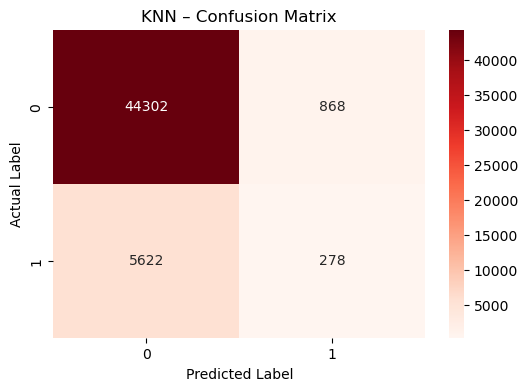

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Reds")

plt.title("KNN – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()
